# VarDyn QG 
This notebook, associated to its configuration file, runs a VarDyn reconstruction for the Gulf Stream region in the eNATL60-BLB002 simulation. 
The model is a 1.5 layer quasi-geostrophic model, and the reduced basis is made of empirical modes with a spatially variable time decorrelation scale. 
The observations are nadir along-track SSH observations from 6 different altimetry missions (AL, C2, H2B, J3, S3A and S3B) and SWOT swath SSH observations. 

In [ ]:
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = ''    
from datetime import datetime

## Configuration file

In [2]:
# BLB002
# path_config = '/data2/nora/Workdir/VarDyn/configs_runs/BLB002/config_VarDyn-QG_barotrop_eNATL60-BLB002.py' 

# BLBT02
# path_config = '/data2/nora/Workdir/VarDyn/configs_runs/BLBT02/config_VarDyn-QG_barotrop_eNATL60-BLBT02.py' 

#SWOT BLBT02
path_config = '/data2/nora/Workdir/VarDyn/configs_runs/SWOT/config_VarDyn-QG_eNATL60-BLBT02_SWOT.py'

In [3]:
import sys
sys.path.append('/home/nora/VarDyn/mapping')

In [4]:

from src import exp
config = exp.Exp(path_config)

name_experiment: VarDyn-QG_eNATL60-BLBT02_Azores_1y_SWOT_21_04
saveoutputs: True
name_exp_save: VarDyn-QG_eNATL60-BLBT02_Azores_1y_SWOT_21_04
path_save: /data2/nora/Workdir/VarDyn/outputs/BLBT02/SWOT/VarDyn-QG_eNATL60-BLBT02_Azores_1y_SWOT_21_04
tmp_DA_path: /data2/nora/Workdir/VarDyn/scratch/VarDyn-QG_eNATL60-BLBT02_Azores_1y_SWOT_21_04
init_date: 2009-07-11 00:00:00
final_date: 2010-02-16 00:00:00
assimilation_time_step: 6:00:00
saveoutput_time_step: 6:00:00
flag_plot: 1
write_obs: True
path_obs: /data2/nora/Workdir/VarDyn/obs
compute_obs: True
name_lon: lon
name_lat: lat
name_time: time
plot_time_step: 1 day, 0:00:00
time_obs_min: None
time_obs_max: None
lon_obs_min: None
lon_obs_max: None
lat_obs_min: None
lat_obs_max: None



## State

In [5]:
from src import state as state
State = state.State(config)

super: GRID_CAR
lon_min: -33
lon_max: -23
lat_min: 28
lat_max: 38
dx: 10
nx: None
ny: None
name_init_mask: /data1/data/models/eNATL60/BLBT02/coarsened/eNATL60-BLBT02_coarse-5_rolling-10.nc
name_var_mask: {'lon': 'lon', 'lat': 'lat', 'var': 'ssh'}



## Model

super: MOD_DIFF
name_var: {'SSH': 'ssh_barotrop'}
var_to_save: None
name_init_var: {'SSH': 'ssh_barotrop'}
dtmodel: 1800
Kdiffus: 0
SIC_mod: False
init_from_bc: False
dist_sponge_bc: None


super: MOD_QG1L_JAX
name_class: Qgm
name_var: {'SSH': 'ssh'}
name_init_var: {'SSH': 'ssh'}
dir_model: None
var_to_save: None
save_diagnosed_variables: False
save_params: False
upwind: 3
advect_pv: True
advect_tracer: False
dtmodel: 1800
cfl: 0.1
time_scheme: rk2
c0: 2.7
filec_aux: /home/nora/VarDyn/mapping/aux/aux_first_baroclinic_speed.nc
name_var_c: {'lon': 'lon', 'lat': 'lat', 'var': 'c1'}
cmin: 2.0
cmax: None
file_bathy_aux: None
name_var_bathy: {'lon': '', 'lat': '', 'var': ''}
bathy_ratio_max: None
solver: spectral
init_from_bc: True
dist_sponge_bc: None
Kdiffus: 150
Kdiffus_trac: None
bc_trac: OBC
forcing_tracer_from_bc: False
constant_c: True
constant_f: True
f0: None
tile_size: 32
tile_overlap: 16
path_mdt: None
name_var_mdt: None



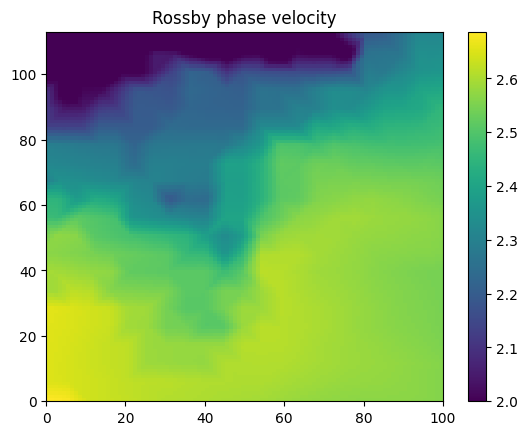

CFL condition for c= 2.425089714500094
Model time-step 400



In [6]:
from src import mod as mod
Model = mod.Model(config,State)

In [7]:
from src import bc as bc
Bc = bc.Bc(config)

super: BC_EXT
file: /data1/data/models/eNATL60/BLBT02/coarsened/eNATL60-BLBT02_coarse-5_rolling-10.nc
name_lon: lon
name_lat: lat
name_time: time
name_var: {'SSH': 'ssh'}
c_grid: False



## Observations

In [8]:
from src import obs as obs
dict_obs = obs.Obs(config,State)

Observation information will be saved in dict_obs_AL_C2_H2B_J3_S3A_S3B_S6A_SWOT_20090711_20100216_-33_-22_28_38_21600.txt

AL:
super: OBS_SSH_NADIR
path: /data1/data/models/eNATL60/BLBT02/obs/nadirs/al.nc
name_time: time
name_lon: lon
name_lat: lat
name_var: {'SSH': 'ssh'}
combine_var: None
synthetic_noise: None
varmax: 100.0
sigma_noise: 0.1
add_mdt: None
substract_mdt: None
path_mdt: None
name_var_mdt: None
path_err: None
name_var_err: None
nudging_params_ssh: None
delta_t: None
velocity: None

--> 255 tracks selected

C2:
super: OBS_SSH_NADIR
path: /data1/data/models/eNATL60/BLBT02/obs/nadirs/c2.nc
name_time: time
name_lon: lon
name_lat: lat
name_var: {'SSH': 'ssh'}
combine_var: None
synthetic_noise: None
varmax: 100.0
sigma_noise: 0.1
add_mdt: None
substract_mdt: None
path_mdt: None
name_var_mdt: None
path_err: None
name_var_err: None
nudging_params_ssh: None
delta_t: None
velocity: None

--> 231 tracks selected

H2B:
super: OBS_SSH_NADIR
path: /data1/data/models/eNATL60/BLBT02/obs

In [9]:
from src import obsop as obsop
Obsop = obsop.Obsop(config,State,dict_obs,Model)

myOBSOP1: super: OBSOP_INTERP_L3_JAX
name_obs: ['AL', 'C2', 'H2B', 'J3', 'S3A', 'S3B', 'S6A']
name_var: SSH
write_op: True
path_save: /data2/nora/Workdir/VarDyn/H
compute_op: True
Npix: 4
mask_borders: False

myOBSOP2: super: OBSOP_INTERP_L4
name_obs: ['SWOT']
name_var: SSH
write_op: True
path_save: /data2/nora/Workdir/VarDyn/H
compute_op: True
mask_borders: False
interp_method: rtree
gradients: False


super: OBSOP_INTERP_L3_JAX
name_obs: ['AL', 'C2', 'H2B', 'J3', 'S3A', 'S3B', 'S6A']
name_var: SSH
write_op: True
path_save: /data2/nora/Workdir/VarDyn/H
compute_op: True
Npix: 4
mask_borders: False

super: OBSOP_INTERP_L4
name_obs: ['SWOT']
name_var: SSH
write_op: True
path_save: /data2/nora/Workdir/VarDyn/H
compute_op: True
mask_borders: False
interp_method: rtree
gradients: False



## Reduced Basis

In [10]:
from src import basis as basis
Basis = basis.Basis(config,State)

super: BASIS_GAUSS3D_JAX
name_mod_var: ssh_barotrop
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: True
facns: 3.0
facnlt: 3.0
sigma_D: 1000
sigma_T: 3
sigma_Q: 0.05
fcor: 0.5
normalize_fact: True
time_spinup: None
flag_variable_Q: False
path_sad: None
name_var_sad: None
path_background: None
var_background: None

super: BASIS_GAUSS3D_JAX
name_mod_var: ssh
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: True
facns: 3.0
facnlt: 3.0
sigma_D: 970
sigma_T: 25
sigma_Q: 0.03
fcor: 0.5
normalize_fact: True
time_spinup: None
flag_variable_Q: False
path_sad: None
name_var_sad: {'lon': '', 'lat': '', 'var': ''}
path_background: None
var_background: None

super: BASIS_BMaux_JAX
name_mod_var: ssh
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: False
facns: 1.0
facnlt: 2.0
npsp: 3.5
facpsp: 1.5
file_aux: /home/nora/VarDyn/mapping/aux/aux_reduced_basis_BM.nc
lmin: 80
lmax: 1000.0
factdec: 7.5
tdecmin: 2.0
tdecmax

## Assimilation

super: INV_4DVAR
flag_full_jax: False
compute_test: False
freq_it_plot: 10
JAX_mem_fraction: None
path_init_4Dvar: None
restart_4Dvar: True
ftol: 1e-05
gtol: None
convergence_nit: None
maxiter: 500
gradient_max_norm: 1000000.0
max_retries: 3
opt_method: L-BFGS-B
save_minimization: True
path_save_control_vectors: /data2/nora/Workdir/VarDyn/controls/BLBT02/SWOT/VarDyn-QG_eNATL60-BLBT02_Azores_1y_SWOT_21_04
timestep_checkpoint: 6:00:00
sigma_R: None
sigma_B: None
prec: True
path_background: None
anomaly_from_bc: False

process observation operators
Processing observations at date 2009-07-23 00:00:00 for variable SSH...
Processing observations at date 2009-07-23 12:00:00 for variable SSH...
Processing observations at date 2009-07-24 00:00:00 for variable SSH...
Processing observations at date 2009-07-24 12:00:00 for variable SSH...
Processing observations at date 2009-07-25 00:00:00 for variable SSH...
Processing observations at date 2009-07-25 12:00:00 for variable SSH...
Processing obser

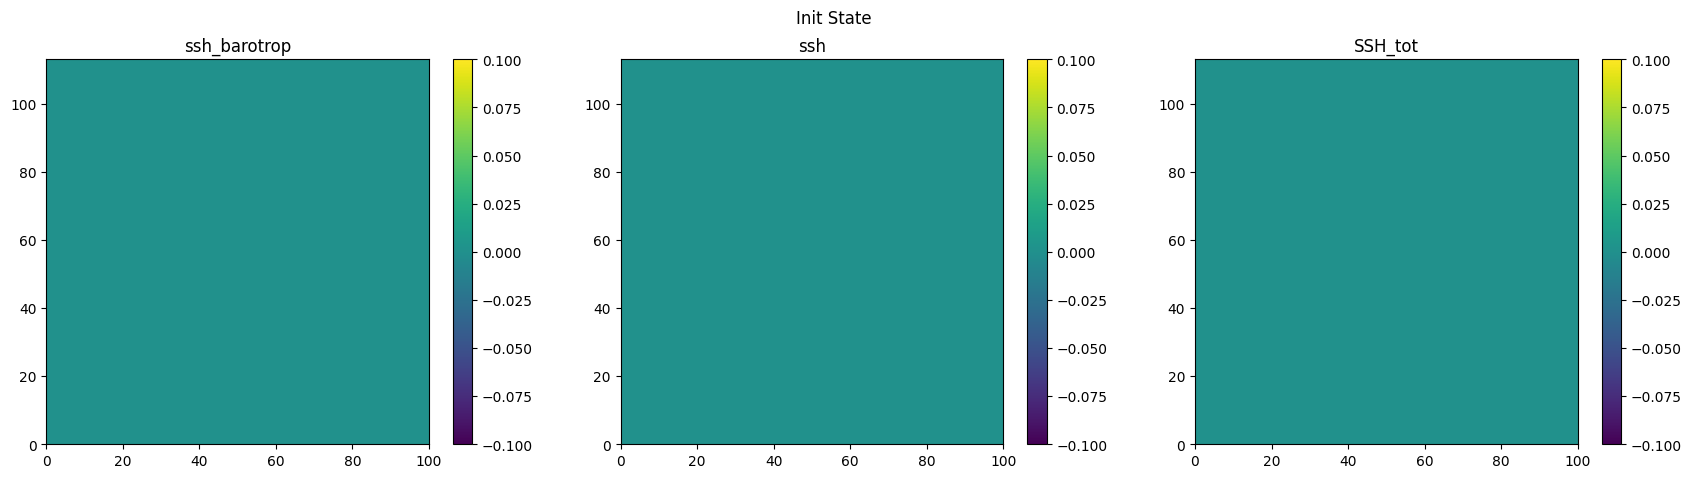

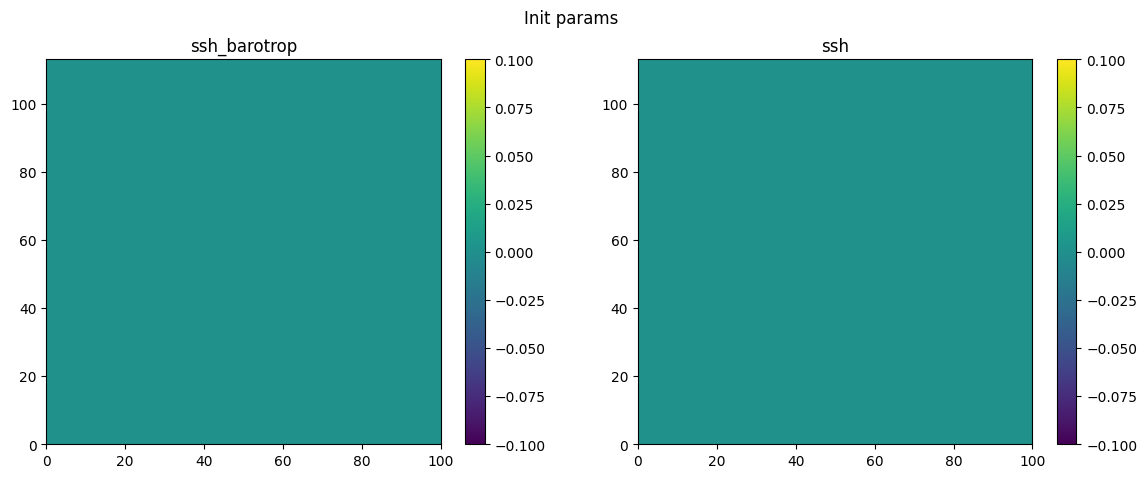

Running basis: <class 'src.basis.Basis_gauss3d_jax'> no_name
lambda=1.0E+03 nlocs=6.1E+01 tdec=3.0E+00 ntime=2.2E+02 Q=1.7E-02
reduced order: 9955300 --> 13664
 reduced factor: 728
Running basis: <class 'src.basis.Basis_gauss3d_jax'> no_name
lambda=9.7E+02 nlocs=6.1E+01 tdec=2.5E+01 ntime=3.0E+01 Q=1.0E-02
reduced order: 9955300 --> 1830
 reduced factor: 5440
Running basis: <class 'src.basis.Basis_bmaux_jax'> no_name
Setting Basis BMaux...
Computing Q
lambda=1.4E+03 nlocs=1.1E+01 tdec=2.0E+00 Q=1.0E-10
lambda=9.7E+02 nlocs=1.5E+01 tdec=1.4E+01 Q=6.9E-04
lambda=6.8E+02 nlocs=1.6E+01 tdec=1.3E+01 Q=1.2E-03
lambda=4.8E+02 nlocs=2.2E+01 tdec=1.1E+01 Q=1.6E-03
lambda=3.3E+02 nlocs=2.4E+01 tdec=9.3E+00 Q=2.1E-03
lambda=2.3E+02 nlocs=3.3E+01 tdec=7.3E+00 Q=1.7E-03
lambda=1.6E+02 nlocs=4.8E+01 tdec=4.6E+00 Q=1.0E-03
lambda=1.1E+02 nlocs=6.6E+01 tdec=2.4E+00 Q=7.5E-04
lambda=8.0E+01 nlocs=1.0E+02 tdec=2.0E+00 Q=6.3E-04
Computing Spatial components
Computing Time components
reduced order: 995530

E0421 10:59:21.243936 2531269 pjrt_stream_executor_client.cc:2916] Execution of replica 0 failed: INTERNAL: Failed to allocate 6040872 bytes for new constant


XlaRuntimeError: INTERNAL: Failed to allocate 6040872 bytes for new constant

In [11]:
from src import inv as inv
inv.Inv(config,State,Model,dict_obs=dict_obs,Obsop=Obsop,Basis=Basis,Bc=Bc)  

## Diagnostics

In [ ]:
from src import diag as diag
Diag = diag.Diag(config,State)

super: DIAG_OSSE
dir_output: /data2/nora/Workdir/VarDyn/diags/BLBT02/avec_barotrope/VarDyn-QG_eNATL60-BLBT02_GulfStream_1y_20_04
time_min: None
time_max: None
time_step: None
lon_min: None
lon_max: None
lat_min: None
lat_max: None
path_images2mp4: /data1/packages/climporn/ffmpeg/images2mp4.sh
name_ref: /data1/data/models/eNATL60/BLBT02/bm/eNATL60-BLBT02_ssh.nc
name_ref_time: time
name_ref_lon: lon
name_ref_lat: lat
name_ref_var: ssh
options_ref: {}
name_exp_time: None
name_exp_lon: None
name_exp_lat: None
name_exp_var: SSH_tot
exp_grid_type: None
compare_to_baseline: False
name_bas: /data2/nora/Workdir/VarDyn/outputs/VarDyn-QG_eNATL60-BLBT02_GulfStream_float32/*.nc
name_bas_time: time
name_bas_lon: lon
name_bas_lat: lat
name_bas_var: ssh
name_mask: None
name_var_mask: {'lon': '', 'lat': '', 'var': ''}



/home/nora/VarDyn/mapping/src/diag.py:141: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  self.ref_dims = list(self.ref.dims.keys())


In [ ]:
Diag.regrid_exp()

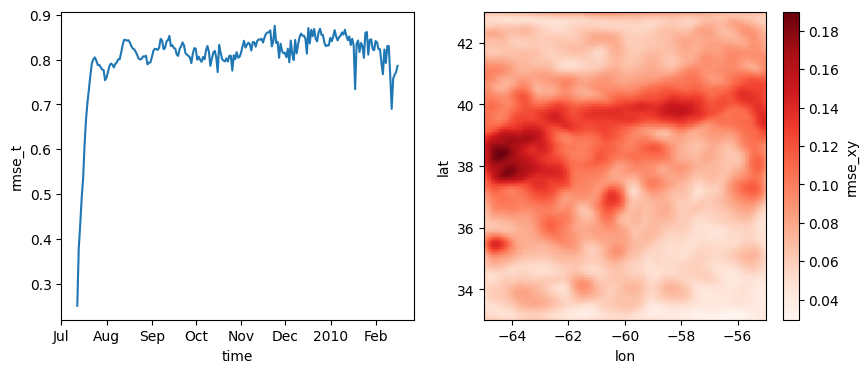

In [ ]:
Diag.rmse_based_scores(plot=True)

/home/nora/miniconda3/envs/env_vardyn/lib/python3.10/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/home/nora/miniconda3/envs/env_vardyn/lib/python3.10/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(


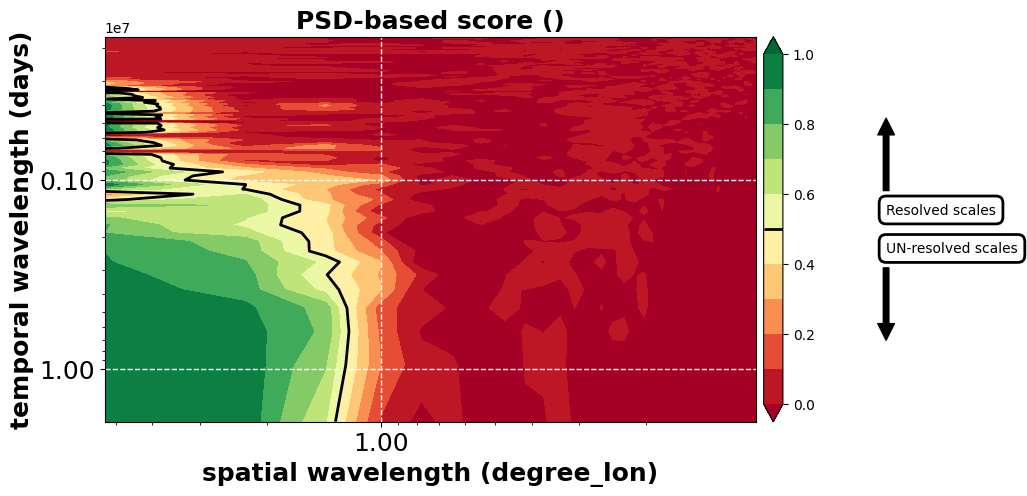

In [ ]:
Diag.psd_based_scores(plot=True)

In [ ]:
Diag.movie(framerate=12, cmap='RdBu_r', clim=[-1,1])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 116 out of 220 | elapsed:    3.9s remaining:    3.5s
[Parallel(n_jobs=-1)]: Done 139 out of 220 | elapsed:    4.2s remaining:    2.4s
[Parallel(n_jobs=-1)]: Done 162 out of 220 | elapsed:    4.5s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done 185 out of 220 | elapsed:    4.6s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done 208 out of 220 | elapsed:    4.7s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done 220 out of 220 | elapsed:    4.8s finished


/data1/packages/climporn/ffmpeg/images2mp4.sh -i /data2/nora/Workdir/VarDyn/diags/BLBT02/avec_barotrope/VarDyn-QG_eNATL60-BLBT02_GulfStream_1y_20_04/frame -f 12 -D /data2/nora/Workdir/VarDyn/diags/BLBT02/avec_barotrope/VarDyn-QG_eNATL60-BLBT02_GulfStream_1y_20_04


ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena


✅ DONE
 → /data2/nora/Workdir/VarDyn/diags/BLBT02/avec_barotrope/VarDyn-QG_eNATL60-BLBT02_GulfStream_1y_20_04/movie_frame_1080px_12fps_loopx1.mp4
Insert into PowerPoint WITHOUT enabling looping.



ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [ ]:
Leaderboard = Diag.Leaderboard()
Leaderboard

,Method,µ(RMSE),σ(RMSE),λx (degree),λt (days)
0,VarDyn-QG_eNATL60-BLBT02_GulfStream_1y_20_04,0.8,0.07,1.21,8.38
